# Setting

## Import packages

In [45]:
# === System & Utility ===
import os
import glob
import re
import time
import json
import math
import itertools
import datetime
from dotenv import load_dotenv
import requests
from urllib.parse import quote

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial & Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### Common functions

#### save_geoDataFrame

In [46]:
def save_geoDataFrame(source_df, filename):
    """
    Save a GeoDataFrame to a CSV file by converting the geometry column to WKT format.

    Parameters:
        source_df (GeoDataFrame): The GeoDataFrame to be saved.
        filename (str): Path to the output CSV file.

    Notes:
        - The geometry column will be converted to WKT strings using shapely.wkt.dumps().
        - The resulting CSV can be restored into a GeoDataFrame using shapely.wkt.loads().
    """
    df = source_df.copy()
    df['geometry'] = df['geometry'].apply(dumps)
    df.to_csv(filename, index=False)

#### load_geoDataFrame

In [47]:
def load_geoDataFrame(filepath):
    """
    Load a GeoDataFrame from a CSV file with a geometry column in WKT format.

    Parameters:
        filepath (str): Path to the CSV file containing the saved GeoDataFrame.

    Returns:
        GeoDataFrame: A GeoDataFrame reconstructed from the CSV, with geometries parsed from WKT strings.
    
    Notes:
        - Assumes the geometry column is named 'geometry' and stored in WKT format.
        - The returned GeoDataFrame is assigned the CRS 'EPSG:4326' by default.
    """
    df = pd.read_csv(filepath)
    df['geometry'] = df['geometry'].apply(loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

#### gen_area_area_mapping

In [48]:
def gen_area_area_mapping(zone_df, grid_df, zone_location_id):
    """
    Maps each polygon in zone_df to intersecting polygons in grid_df using spatial join.

    Parameters:
        zone_df (gpd.GeoDataFrame): GeoDataFrame with zone polygons (must include geometry).
        grid_df (gpd.GeoDataFrame): GeoDataFrame with grid polygons (must include 'grid_id' and geometry).
        zone_location_id (str): Column name in zone_df representing the zone identifier.

    Returns:
        gpd.GeoDataFrame: A DataFrame mapping each grid_id to zone_location_id for all intersecting areas.
                          The resulting dataframe includes ['grid_id', zone_location_id] and geometry columns.
    """
    # Ensure both inputs are GeoDataFrames
    zone_gdf = zone_df.copy()
    grid_gdf = grid_df.copy()

    zone_gdf = zone_gdf.set_geometry('geometry')
    grid_gdf = grid_gdf.set_geometry('geometry')

    # Reproject both to WGS84 if needed
    zone_gdf = zone_gdf.to_crs('EPSG:4326')
    grid_gdf = grid_gdf.to_crs('EPSG:4326')

    # Perform spatial join based on intersection
    zone_to_grid = gpd.sjoin(
        grid_gdf[['grid_id', 'geometry']],
        zone_gdf[[zone_location_id, 'geometry']],
        how='inner',
        predicate='intersects'
    )

    return zone_to_grid

#### gen_point_area_mapping

In [49]:
def gen_point_area_mapping(point_df, lat_col, lon_col, geometry_df, geometry_col='geometry'):
    """
    Maps each point in point_df to a polygon in geometry_df using spatial join.

    Parameters:
        point_df (pd.DataFrame): DataFrame with latitude and longitude columns.
        lat_col (str): Column name for latitude.
        lon_col (str): Column name for longitude.
        geometry_df (gpd.GeoDataFrame): GeoDataFrame containing polygon geometries.
        geometry_col (str): Column name for the geometry column in geometry_df.

    Returns:
        gpd.GeoDataFrame: Result of spatial join with matching polygons.
    """
    # Drop rows with missing coordinates
    point_df = point_df.dropna(subset=[lat_col, lon_col]).copy()

    # Convert to GeoDataFrame
    point_gdf = gpd.GeoDataFrame(
        point_df,
        geometry=gpd.points_from_xy(point_df[lon_col], point_df[lat_col]),
        crs="EPSG:4326"
    )

    # Ensure geometry_df is a GeoDataFrame with proper CRS
    area_gdf = geometry_df.copy()
    if geometry_col != 'geometry':
        area_gdf = area_gdf.set_geometry(geometry_col)
    if area_gdf.crs != "EPSG:4326":
        area_gdf = area_gdf.to_crs("EPSG:4326")

    # Perform spatial join
    joined = gpd.sjoin(point_gdf, area_gdf, how='inner', predicate='within')

    return joined

#### plot_busyness_map

In [50]:
def plot_busyness_map(df, busyness_level, date_str, hour_int, ax=None, figsize=(6, 6), cmap='OrRd'):
    """
    Plot a busyness heatmap on a grid-based map using a specified busyness level column.

    Parameters:
        df (pd.DataFrame): Input DataFrame containing a 'geometry' column.
        busyness_level (str): Column name to visualize (e.g., 'predicted_busyness_level').
        date_str (str): Date label for the plot title (e.g., '2025-07-03').
        hour_int (int): Hour of day (0–23) to include in the plot title.
        ax (matplotlib.axes.Axes, optional): Axes to plot on. If None, creates a new plot.
        figsize (tuple, optional): Size of the figure if ax is None.
        cmap (str, optional): Color map for the heatmap.
    """
    # Convert to GeoDataFrame and reproject to Web Mercator
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)

    # Drop rows with missing busyness values
    gdf = gdf.dropna(subset=[busyness_level])

    # Create new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Plot the busyness heatmap
    gdf.plot(
        ax=ax,
        column=busyness_level,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        legend_kwds={'label': busyness_level}
    )

    ax.set_title(f"{busyness_level} - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")

### Event

#### fetch_manhattan_events_in_range

In [51]:
def fetch_manhattan_events_in_range(target_datetime, duration_hour=1):
    """
    Fetch public events happening in Manhattan that overlap a given time window.

    Parameters:
        target_datetime (str or datetime-like): The center of the time window.
        duration_hour (int, optional): Length of the window in hours (default: 1).
                                       The function will create a time window starting from the rounded hour of `target_datetime`.

    Returns:
        pd.DataFrame: A DataFrame of event records including:
                      - event_id
                      - start_date_time
                      - end_date_time
                      - event_location
    """
    # Compute time window
    start_time = pd.to_datetime(target_datetime).round('h')
    end_time = start_time + pd.Timedelta(hours=duration_hour)
    print(start_time)
    print(end_time)

    s_iso = start_time.strftime('%Y-%m-%dT%H:%M:%S')
    e_iso = end_time.strftime('%Y-%m-%dT%H:%M:%S')
    
    # Build SoQL query
    where_clause = f"""
    SELECT
      event_id,
      start_date_time AS start_time,
      end_date_time AS end_time,
      event_location
    WHERE
      (start_date_time <= "{e_iso}" :: floating_timestamp)
      AND (end_date_time >= "{s_iso}" :: floating_timestamp)
      AND caseless_one_of(event_borough, "Manhattan")
    GROUP BY event_id, start_date_time, end_date_time, event_location
    """
    
    encoded_query = quote(where_clause, safe="")
    url = f"https://data.cityofnewyork.us/resource/tvpp-9vvx.json?$query={encoded_query}"

    # Fetch data
    response = requests.get(url)
    if response.status_code == 200:
        raw_event_df = pd.DataFrame(response.json())
        print(f"✅ Fetched {raw_event_df.shape[0]} events.")
        return raw_event_df
    else:
        print(f"❌ Failed to fetch events: HTTP {response.status_code}")
        return pd.DataFrame()

#### extract_main_location

In [52]:
def extract_main_location(text):
    match_colon = re.match(r"^(.*?):", text)
    if match_colon:
        return match_colon.group(1).strip()

    match_between = re.match(r"^(.*?)\s+between\s+", text, re.IGNORECASE)
    if match_between:
        return match_between.group(1).strip()

    return text

#### get_event_geometry

In [53]:
def get_event_geometry(location_name, buffer_radius_m=200, city_prefix="Manhattan, New York, NY", pause=1.0):
    """
    Get geometry for a location using polygon (OSM) or buffered point (fallback).

    Parameters:
        location_name (str): The name of the event/location.
        buffer_radius_m (float): Fallback buffer radius in meters.
        city_prefix (str): Prefix to help disambiguate location.
        pause (float): Seconds to sleep between geocoding queries.

    Returns:
        geometry (shapely.geometry): Polygon or buffered point.
        source (str): 'polygon' if from OSM, 'buffer' if fallback point used, or 'failed'.
    """
    geolocator = Nominatim(user_agent="geo_fallback")
    full_location = f"{location_name}, {city_prefix}"

    # Try OSMnx polygon
    try:
        gdf = ox.geocode_to_gdf(full_location)
        if not gdf.empty and gdf.geometry.iloc[0].geom_type in ['Polygon', 'MultiPolygon']:
            return gdf.geometry.iloc[0], 'polygon'
    except Exception as e:
        pass

    # Pause to respect geocoding API limits
    time.sleep(pause)

    # Fallback: geopy + buffer
    try:
        loc = geolocator.geocode(full_location)
        if loc:
            point = Point(loc.longitude, loc.latitude)
            buffer_radius_deg = buffer_radius_m / 111000  # ~1 deg = 111km
            return point.buffer(buffer_radius_deg), 'buffer'
    except Exception as e:
        pass

    return None, 'failed'

#### standardize_address

In [54]:
def standardize_address(text):
    text = text.upper()
    text = text.replace('WEST', 'W')
    text = text.replace('EAST', 'E')
    text = text.replace('STREET', 'St')
    text = text.replace('AVENUE', 'Ave')
    text = text.replace(' BOULEVARD', ' Blvd')
    text = text.replace(' PLACE', ' Pl')
    text = text.replace(' ROAD', ' Rd')
    text = text.replace(' CIRCLE', ' Cir')
    return text

#### fill_missing_geometry_with_osm

In [55]:
def fill_missing_geometry_with_osm(location_df, location_col):
    """
    Fill missing geometry values in the location DataFrame using OSM-based geocoding.

    This function applies a geocoding function (`get_event_geometry`) to entries
    where the 'geometry' column is missing. It updates the DataFrame in-place
    with the fetched geometry and source type.

    Parameters:
        location_df (pd.DataFrame): A DataFrame containing location data, including a column for geometry.
        location_col (str): The name of the column containing standardized location strings to geocode.

    Returns:
        pd.DataFrame: The input DataFrame with missing geometry entries filled where possible.
                      Adds or updates a 'source_type' column indicating the data source.
    """
    missing_geometry_df = location_df[location_df['geometry'].isna()]
    
    for i, row in missing_geometry_df.iterrows():
        geom, src = get_event_geometry(row[location_col])
        location_df.at[i, 'geometry'] = geom
        location_df.at[i, 'source_type'] = src
        print(i, row['main_location'], geom, src)

    return location_df

#### fill_missing_geometry_with_google_api

In [56]:
def fill_missing_geometry_with_google_api(location_df,
                                        location_col='fixed_main_location',
                                        api_key=None,
                                        buffer_radius_m=200,
                                        sleep_time=1.0):
    """
    Use Google Maps API to fill in missing geometry with a buffered point.

    Parameters:
        location_df (pd.DataFrame): DataFrame with a 'fixed_main_location' column.
        location_col (str): Column with standardized location names.
        api_key (str): Google Maps API key.
        buffer_radius_m (float): Buffer radius in meters.
        sleep_time (float): Seconds to pause between API calls.

    Returns:
        pd.DataFrame: Updated DataFrame with 'geometry' and 'source_type'.
    """
    assert api_key, "Google Maps API key (api_key) is required."
    buffer_radius_deg = buffer_radius_m / 111000  # ~1 degree ≈ 111 km

    for i, row in location_df[location_df['geometry'].isna()].iterrows():
        try:
            query = f"{row[location_col]}, Manhattan, New York, NY"
            url = f"https://maps.googleapis.com/maps/api/geocode/json?address={query}&key={api_key}"
            response = requests.get(url).json()

            if response['status'] == 'OK' and response['results']:
                location = response['results'][0]['geometry']['location']
                lat, lon = location['lat'], location['lng']
                point = Point(lon, lat)
                location_df.at[i, 'geometry'] = point.buffer(buffer_radius_deg)
                location_df.at[i, 'source_type'] = 'google'

                print(f"{i}: {query} → ({lat}, {lon})")
            else:
                print(f"❌ Could not resolve location: {query}")
        except Exception as e:
            print(f"⚠️ Error @ {row[location_col]}: {e}")

        time.sleep(sleep_time)

    return location_df

#### expand_event_to_hourly_grid

In [57]:
def expand_event_to_hourly_grid(merged_event_df):
    expanded_rows = []
    for _, row in merged_event_df.iterrows():
        hours = pd.date_range(start=row['start_time'], end=row['end_time'], freq='h')
        for h in hours:
            expanded_rows.append({'event_hour': h, 'grid_id': row['grid_id']})

    hourly_df = pd.DataFrame(expanded_rows)
    hourly_df['event_rounded_hour'] = hourly_df['event_hour'].dt.floor('h')
    hourly_count = (
        hourly_df.groupby(['event_rounded_hour', 'grid_id'])
        .size()
        .reset_index(name='event_count')
    )
    hourly_count['date'] = hourly_count['event_rounded_hour'].dt.date
    hourly_count['hour'] = hourly_count['event_rounded_hour'].dt.hour.astype(int)
    return hourly_count

#### resolve_event_geometry

In [58]:
def resolve_event_geometry(raw_event_df):
    """
    Resolve geometries for event locations using a multi-step strategy:

    1. Cached Matching:
       - Try to match `main_location` against known geometries in `location_df.csv`.

    2. OSM Geocoding (Fallback #1):
       - For unmatched entries, standardize the location string and use OpenStreetMap (e.g., Nominatim) to retrieve:
         - Polygon geometry (preferred), or
         - Point geometry buffered by 200 meters.

    3. Google Maps API (Fallback #2):
       - If OSM fails, use the Google Maps Geocoding API to retrieve point geometry (buffered by 200 meters).

    4. Filtering:
       - Drop any records still lacking geometry after both geocoding steps.

    5. Update Mapping:
       - Append newly resolved `main_location` → `geometry` pairs to `location_df.csv` for future reuse.

    Parameters:
        raw_event_df (pd.DataFrame): DataFrame with at least a 'main_location' column.

    Returns:
        pd.DataFrame: Updated event DataFrame with resolved geometries.
    """
    
    # Step 1: Load cached location-to-geometry mapping
    location_df = load_geoDataFrame('save_to_database/location_df.csv')
    raw_event_df['main_location'] = raw_event_df['event_location'].apply(extract_main_location)
    event_df = raw_event_df.merge(location_df[['main_location', 'geometry']], on='main_location', how='left')
    
    # Step 2: Use standardized addresses and OSM geocoding for missing geometries
    event_df['fixed_main_location'] = event_df['main_location'].apply(standardize_address)
    event_df = fill_missing_geometry_with_osm(location_df=event_df,
                                              location_col='fixed_main_location')
    
    # Step 3: Use Google Maps API to fill remaining missing geometries
    load_dotenv()
    google_api_key = os.getenv("GOOGLE_API_KEY")
    event_df = fill_missing_geometry_with_google_api(location_df=event_df,
                                                     location_col='main_location',
                                                     api_key=google_api_key)
    
    # Step 4: Drop records still lacking geometry
    event_df = event_df[event_df['geometry'].notna()]
    
    # Step 5: Update the cached location-to-geometry mapping file
    new_location_mapping = event_df[~event_df['main_location'].isin(location_df['main_location'])][['main_location', 'geometry']]
    fixed_location_df = location_df[['main_location', 'geometry']]
    fixed_location_df = pd.concat([fixed_location_df, new_location_mapping])
    save_geoDataFrame(source_df=fixed_location_df,
                      filename='../data_preparation/prepared_outputs/location_df.csv')

    return event_df

#### get_hourly_grid_event

In [59]:
def get_hourly_grid_event(target_datetime, duration_hour=1):
    """
    Aggregate public event counts per Manhattan grid cell over a specified hourly window.

    Steps:
    1. Fetch public events overlapping with the specified time window using NYC Open Data.
    2. Resolve each event’s geometry via:
       - Cached location mapping (`location_df.csv`)
       - OpenStreetMap geocoding (fallback)
       - Google Maps API (fallback)
    3. Update the local location mapping file with any new resolutions.
    4. Match each event to intersecting Manhattan grid cells.
    5. Expand events to hourly granularity and count events per grid per hour.
    6. Return only the hourly counts that fall within the specified time window.

    Parameters:
        target_datetime (str or datetime-like): Start time for the query. Rounded to the nearest hour.
        duration_hour (int, optional): Number of hours to include from the start time. Default is 1.

    Returns:
        pd.DataFrame: DataFrame with columns ['event_rounded_hour', 'grid_id', 'event_count'] 
                      covering the specified time window.
    """
    
    # Step 1: Fetch raw events overlapping with the time window
    raw_event_df = fetch_manhattan_events_in_range(target_datetime, duration_hour)

    # Step 2: Resolve geometry via cached + geocoded sources
    event_df = resolve_event_geometry(raw_event_df)
    
    # Step 3: Load Manhattan spatial grid
    grid_df = load_geoDataFrame('manhattan_grid/manhattan_grid.csv')

    # Step 4: Map event locations to intersecting grid cells
    event_zone = event_df[['main_location', 'geometry']].drop_duplicates()
    event_zone_to_grid = gen_area_area_mapping(zone_df=event_zone, 
                                               grid_df=grid_df,
                                               zone_location_id='main_location')

    # Step 5: Merge grid IDs into the event records
    merged_event_df = event_df.merge(event_zone_to_grid[['main_location', 'grid_id']], on='main_location')
    merged_event_df['start_time'] = pd.to_datetime(merged_event_df['start_time'])
    merged_event_df['end_time'] = pd.to_datetime(merged_event_df['end_time'])

    # Step 6: Expand events into hourly records and count per grid
    event_hourly_count = expand_event_to_hourly_grid(merged_event_df)

    # Step 7: Filter to requested hour range
    start_time = pd.to_datetime(target_datetime).round('h')
    end_time = start_time + pd.Timedelta(hours=duration_hour)
    target_event_df = event_hourly_count[(event_hourly_count['event_rounded_hour'] >= start_time) & (event_hourly_count['event_rounded_hour'] < end_time)]
    return target_event_df[['grid_id', 'event_count', 'date', 'hour']]

### Weather

#### get_manhattan_weather_forecast

In [60]:
def get_manhattan_weather_forecast(target_datetime):
    """
    Fetch weather data for Manhattan from the OpenWeather One Call API 3.0.
    * Since NCEI does not offer hourly weather forecasts, the data is retrieved from OpenWeather using the same latitude and longitude as the training data.

    Depending on how far `target_datetime` is from now, the function retrieves:
    - current weather (if target is "now")
    - hourly forecast (if within 48 hours)
    - daily forecast (if between 2 and 7 days)

    Parameters:
        target_datetime (str or datetime-like): Target datetime to fetch weather for. e.g. '2025-06-30 23:59:20'

    Returns:
        pd.DataFrame: DataFrame containing 'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm' if available,
                      or None if out of forecast range
    """
    # Round times to the nearest hour
    target_datetime = pd.to_datetime(target_datetime).round('h')
    current_datetime = pd.to_datetime(datetime.datetime.now()).round('h')
    
    # If target is beyond the API's range (8 days), exit early
    if (target_datetime - current_datetime) > datetime.timedelta(days=8):
        print("❗ Can only predict weather up to 7 days in advance.")
        return None
    elif target_datetime < current_datetime:
        print("❗ Cannot predict weather in the past.")
        return None
        
    # Manhattan coordinates
    lat = 40.77898
    lon = -73.96925

    # Load API key from .env
    load_dotenv()
    api_key = os.getenv("OPEN_WEATHER_API")

    # Construct One Call API request
    url = (
        f"https://api.openweathermap.org/data/3.0/onecall?"
        f"lat={lat}&lon={lon}&exclude=minutely,alerts&units=metric&appid={api_key}"
    )
    
    response = requests.get(url)
    data = response.json()

    # Case 1: current weather
    if target_datetime == current_datetime:
        weather_df = pd.DataFrame(data['current'])
        weather_df['temp_c'] = weather_df['temp']
        
    # Case 2: within 48 hours → use hourly forecast
    elif (target_datetime - current_datetime) < datetime.timedelta(hours=48):
        hourly_df = pd.DataFrame(data['hourly'])
        hourly_df['datetime'] = pd.to_datetime(hourly_df['dt'], unit='s')
        weather_df = hourly_df[hourly_df['datetime'] == target_datetime].copy()
        weather_df['temp_c'] = weather_df['temp']

    # Case 3: beyond 48 hours → use daily forecast
    else:
        daily_df = pd.DataFrame(data['daily'])
        daily_df['datetime'] = pd.to_datetime(daily_df['dt'], unit='s')
        daily_df['temp_c'] = daily_df['temp'].apply(lambda x: x['day'])
        daily_df['rain'] = daily_df['rain'].astype('float').fillna(0)
        daily_df['precip_mm'] = daily_df['rain']/24
        weather_df = daily_df[daily_df['datetime'].dt.date == target_datetime.date()].copy()

    weather_df.loc[:, 'wind_speed_knot'] = weather_df['wind_speed'] * 1.94384
    weather_df.loc[:, 'precip_mm'] = weather_df.apply(
        lambda row: row['rain']['1h'] if isinstance(row.get('rain'), dict) and '1h' in row['rain'] else 0,
        axis=1
    )
    # Return only selected columns if available
    weather_df = weather_df.rename(columns={'dew_point': 'dew_c'})
    return weather_df[['temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm']].reset_index(drop=True)

### Prediction

#### gen_pred_features

In [61]:
def get_features_with_geometry(target_datetime):
    """
    Generate a feature DataFrame for prediction at a given datetime, including geometry for mapping purposes.

    This function prepares spatial and temporal features required for prediction models, such as weather,
    event count, time components, and static grid attributes. It also includes a 'geometry' column for visualization,
    though it is not used in modeling.

    Parameters:
        target_datetime (str or datetime-like): The datetime to generate features for. Will be used to fetch
                                                weather and event data and derive time-related features.

    Returns:
        pd.DataFrame: A DataFrame containing the following:
            - Predictive features: temporal (month, day, hour, etc.), weather, population, restaurant count, event count
            - Spatial metadata: latitude, longitude, grid_id
            - Geometry column for map visualization (not used in prediction)
    """
    
    # Read CSV files (should be replaced with reading from database)
    grid_info = load_geoDataFrame('../data_preparation/prepared_outputs/grid_info.csv')
    holiday_df = pd.read_csv('../data_preparation/prepared_outputs/holiday_df.csv')
    holiday_df['holiday_date'] = pd.to_datetime(holiday_df['holiday_date'])

    # get weather_df, event_df
    weather_df = get_manhattan_weather_forecast(target_datetime=target_datetime)
    event_df = get_hourly_grid_event(target_datetime=target_datetime, duration_hour=1)

    feature_df = grid_info.merge(weather_df, how='cross')
    feature_df = feature_df.merge(event_df, how='left', on='grid_id')
    feature_df['datetime'] = pd.to_datetime(target_datetime)
    feature_df['event_count'] = feature_df['event_count'].fillna(0)
    
    # Extract more date related data and convert them to category datatype
    feature_df['grid_id'] = feature_df['grid_id'].astype('category')
    feature_df['month'] = feature_df['datetime'].dt.month.astype('category')
    feature_df['weekofyear'] = feature_df['datetime'].dt.isocalendar().week.astype('category')
    feature_df['dayofweek'] = feature_df['datetime'].dt.dayofweek.astype('category')
    feature_df['day'] = feature_df['datetime'].dt.day.astype('category')
    feature_df['hour'] = feature_df['datetime'].dt.hour.astype('category')
    feature_df['is_holiday'] = pd.to_datetime(pd.to_datetime(target_datetime).date()) in holiday_df['holiday_date'].values
    feature_df['is_holiday'] = feature_df['is_holiday'].astype('category')
    feature_df['is_weekend'] = (feature_df['dayofweek'].astype('int') >= 5).astype('category')


    feature_df = feature_df[['month', 'weekofyear', 'dayofweek', 'is_weekend', 'day', 'hour', 'is_holiday',
                        'temp_c', 'dew_c', 'wind_speed_knot', 'precip_mm',
                        'grid_id', 'restaurant_count', 'population',
                        'lat', 'lon',
                        'event_count', 'geometry'
                       ]]
    return feature_df

# Grid Basic Information
- Grid basic information includes `grid_id`, `lat`, `lon`, `restaurant_count`, `population`, `geometry`
- `grid_info.csv'` should be saved as a table in database for easier access

In [62]:
# Load datasets
inspection_df = pd.read_csv('../data_preparation/inspection/Inspection_latest_Results_cleaned_step2.csv')
grid_df = load_geoDataFrame('../data_preparation/manhattan_grid/manhattan_grid.csv')
population_df = load_geoDataFrame('../data_preparation/population/census_data_2020.csv')

# Convert to correct data type
population_df['population'] = population_df['population'].str.replace(',', '').astype('int')

In [63]:
# Map inspection points to grids and count restaurants per grid
inspection_joined = gen_point_area_mapping(point_df=inspection_df,
                                           lat_col='Latitude',
                                           lon_col='Longitude',
                                           geometry_df=grid_df,
                                           geometry_col='geometry')
restaurant_counts = inspection_joined.groupby('grid_id').size().reset_index(name='restaurant_count')
grid_info = grid_df.merge(restaurant_counts, on='grid_id', how='left').fillna(0)

# Assign population weights based on restaurant density
grid_info['weighted'] = (grid_info['restaurant_count'] // 10).astype('int') + 1

# Distribute population from taxi zones to grids using weights
zone_to_grid = gen_area_area_mapping(zone_df=population_df, 
                                     grid_df=grid_df,
                                     zone_location_id='NAMELSAD')
zone_to_grid = zone_to_grid.merge(grid_info[['grid_id', 'weighted']], on='grid_id')
zone_to_grid['location_tot_weighted'] = zone_to_grid.groupby('NAMELSAD')['weighted'].transform('sum')
zone_to_grid['percentage'] = zone_to_grid['weighted'] / zone_to_grid['location_tot_weighted']

# Allocate weighted population to each grid
merged_population_df = population_df.merge(zone_to_grid[['NAMELSAD', 'grid_id', 'percentage']], on='NAMELSAD')
merged_population_df['weighted_population'] = (merged_population_df['population'] * merged_population_df['percentage']).astype('int')
merged_population_df = merged_population_df.groupby('grid_id')['weighted_population'].sum().reset_index(name='population')

# Merge population into grid info
grid_info = grid_info.merge(merged_population_df, on='grid_id', how='left').fillna(0)
grid_info.head()

,grid_id,lat,lon,geometry,restaurant_count,weighted,population
0,M-0001,40.6840,-74.0257,"POLYGON ((-74.0242 40.68292, -74.0242 40.68517...",0.0,1,0.0
1,M-0002,40.6840,-74.0227,"POLYGON ((-74.02126 40.68292, -74.02126 40.685...",0.0,1,0.0
2,M-0003,40.6840,-74.0198,"POLYGON ((-74.01832 40.68292, -74.01832 40.685...",0.0,1,0.0
3,M-0004,40.6863,-74.0257,"POLYGON ((-74.0242 40.68517, -74.0242 40.68742...",0.0,1,0.0
4,M-0005,40.6863,-74.0227,"POLYGON ((-74.02126 40.68517, -74.02126 40.687...",0.0,1,0.0


In [64]:
save_geoDataFrame(source_df=grid_info,
                      filename='../data_preparation/prepared_outputs/grid_info.csv')

C:\Users\xiaoxiajin\AppData\Local\Temp\ipykernel_2604\1955781453.py:14: UserWarning: Geometry column does not contain geometry.
  df['geometry'] = df['geometry'].apply(dumps)


# Holiday
- `holiday_df.csv` could be saved as a table in the database for easier access

In [65]:
holiday_raw = pd.read_csv('../data_preparation/holiday_module/Holiday/holidays.csv')
holiday_raw['start_date'] = pd.to_datetime(holiday_raw['start_date'])
holiday_raw['end_date'] = pd.to_datetime(holiday_raw['end_date'])

all_holidays = set()

for _, row in holiday_raw.iterrows():
    date_range = pd.date_range(row['start_date'], row['end_date'])
    all_holidays.update(date_range.date)

# Create DataFrame of individual holiday dates
holiday_df = pd.DataFrame(sorted(all_holidays), columns=['holiday_date'])
holiday_df['holiday_date'] = pd.to_datetime(holiday_df['holiday_date'])
holiday_df.to_csv('../data_preparation/prepared_outputs/holiday_df.csv', index=False)
holiday_df.head()

,holiday_date
0,2025-01-01
1,2025-01-02
2,2025-01-09
3,2025-01-10
4,2025-01-20


# Prediction

In [ ]:
target_datetime = '2025-07-13 12:00:00'
feature_df = get_features_with_geometry(target_datetime=target_datetime)

In [67]:
import joblib

model = joblib.load('lgbm_model_v2.pkl')

In [ ]:
predictions = model.predict(feature_df.drop(columns='geometry'))
predictions

In [ ]:
result_df = feature_df.copy()
result_df['predicted_busyness_level'] = predictions
result_df['predicted_busyness_level'] = result_df['predicted_busyness_level'] + 1

In [ ]:
result_df[result_df['predicted_busyness_level'] == 5].sort_values('restaurant_count', ascending=False)['grid_id'].to_list()

['M-0351',
 'M-0417',
 'M-0319',
 'M-0374',
 'M-0356',
 'M-0212',
 'M-0433',
 'M-0155',
 'M-0474',
 'M-0352',
 'M-0227',
 'M-0126',
 'M-0393',
 'M-0454',
 'M-0392',
 'M-0413',
 'M-0303',
 'M-0391',
 'M-0495',
 'M-0357',
 'M-0411',
 'M-0076',
 'M-0591',
 'M-0201',
 'M-0091',
 'M-0274',
 'M-0244',
 'M-0231',
 'M-0600',
 'M-0219',
 'M-0185',
 'M-0335',
 'M-0348',
 'M-0375',
 'M-0459',
 'M-0287',
 'M-0139',
 'M-0455',
 'M-0213',
 'M-0245',
 'M-0270',
 'M-0282',
 'M-0169',
 'M-0387',
 'M-0336',
 'M-0269',
 'M-0157',
 'M-0257',
 'M-0476',
 'M-0496',
 'M-0576',
 'M-0119']

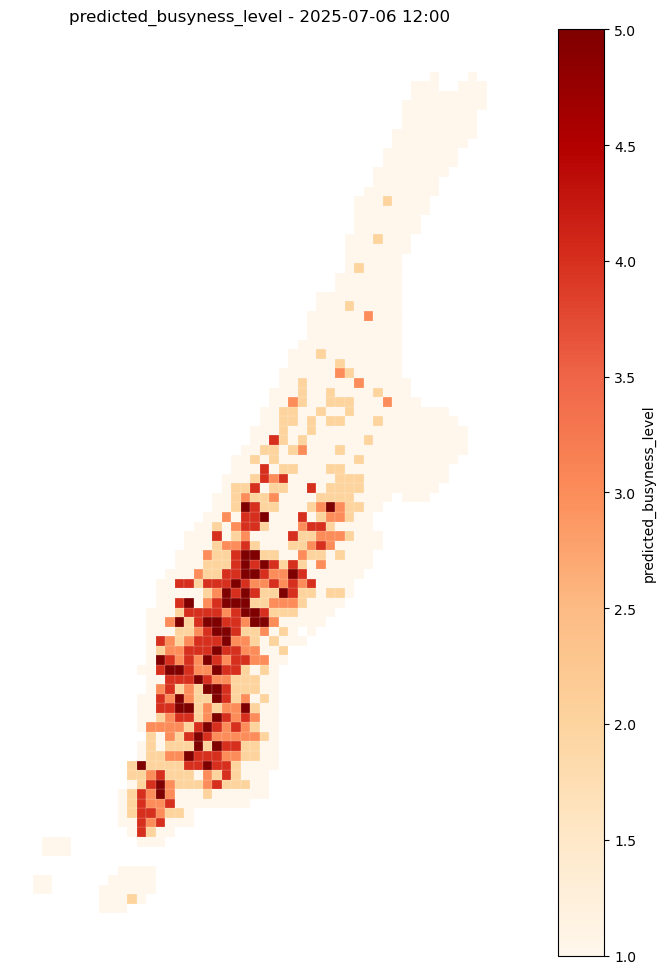

In [ ]:
target_date = str(pd.to_datetime(target_datetime).date())
target_hour = pd.to_datetime(target_datetime).hour

plot_busyness_map(result_df, 'predicted_busyness_level', target_date, target_hour, figsize=(10, 10))

plt.tight_layout()
plt.show()